In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("movies.csv")
df.head(3)

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes


In [3]:
# Drop rows where budget OR revenue is 0
df = df[(df["budget"] > 0) & (df["revenue"] > 0)].copy()
print(f"After removing zero budget/revenue: {df.shape[0]} rows")

# Parse primary genre
def extract_first_genre(genre_str):
    try:
        genres = ast.literal_eval(genre_str)
        return genres[0]["name"] if genres else "Unknown"
    except Exception:
        return "Unknown"

# Parse primary production company
def extract_first_company(comp_str):
    try:
        companies = ast.literal_eval(comp_str)
        return companies[0]["name"] if companies else "Unknown"
    except Exception:
        return "Unknown"

df["primary_genre"]   = df["genres"].apply(extract_first_genre)
df["primary_company"] = df["production_companies"].apply(extract_first_company)

# Fix runtime and director nulls
df["runtime"] = pd.to_numeric(df["runtime"], errors="coerce")
df["runtime"].fillna(df["runtime"].median(), inplace=True)
df["director"].fillna("Unknown", inplace=True)

print("\nMissing values after cleaning:")
print(df[["budget","revenue","runtime","director","primary_genre"]].isnull().sum())

After removing zero budget/revenue: 3229 rows

Missing values after cleaning:
budget           0
revenue          0
runtime          0
director         0
primary_genre    0
dtype: int64


/tmp/ipykernel_21257/3446013194.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["runtime"].fillna(df["runtime"].median(), inplace=True)
/tmp/ipykernel_21257/3446013194.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [4]:
df["success"] = (df["revenue"] > df["budget"]).astype(int)

counts = df["success"].value_counts().rename({1: "Success", 0: "Failure"})
print("Class distribution:")
print(counts)
print(f"\nOverall success rate: {df['success'].mean():.1%}")

Class distribution:
success
Success    2438
Failure     791
Name: count, dtype: int64

Overall success rate: 75.5%


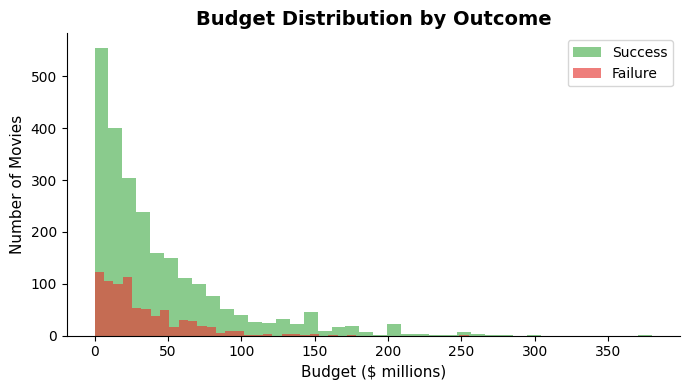

In [5]:
# Fig 2: Budget distribution by label
fig, ax = plt.subplots(figsize=(7, 4))
for label, color in [("Success", "#4CAF50"), ("Failure", "#E53935")]:
    subset = df[df["success"] == (1 if label == "Success" else 0)]["budget"] / 1e6
    ax.hist(subset, bins=40, alpha=0.65, color=color, label=label, edgecolor="none")
ax.set_xlabel("Budget ($ millions)", fontsize=11)
ax.set_ylabel("Number of Movies", fontsize=11)
ax.set_title("Budget Distribution by Outcome", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [6]:
le_genre    = LabelEncoder()
le_company  = LabelEncoder()
le_director = LabelEncoder()

df["genre_encoded"]    = le_genre.fit_transform(df["primary_genre"])
df["company_encoded"]  = le_company.fit_transform(df["primary_company"])
df["director_encoded"] = le_director.fit_transform(df["director"])

features = ["budget", "runtime", "vote_average",
            "genre_encoded", "company_encoded", "director_encoded"]

X = df[features].values
y = df["success"].values

print("Feature matrix shape:", X.shape)
print("Label distribution:", dict(zip(*np.unique(y, return_counts=True))))

Feature matrix shape: (3229, 6)
Label distribution: {np.int64(0): np.int64(791), np.int64(1): np.int64(2438)}


In [9]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

print("── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=["Failure", "Success"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")

── Classification Report ──
              precision    recall  f1-score   support

     Failure       0.58      0.07      0.12       158
     Success       0.77      0.98      0.86       488

    accuracy                           0.76       646
   macro avg       0.67      0.53      0.49       646
weighted avg       0.72      0.76      0.68       646

ROC-AUC Score: 0.675


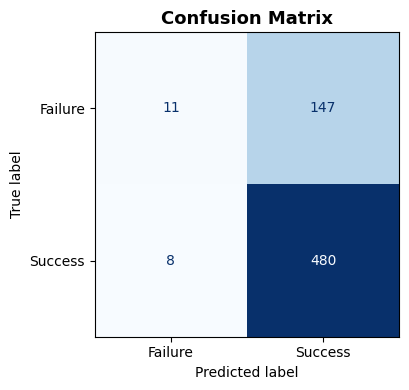

In [10]:
# Fig 4: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=["Failure", "Success"]).plot(
    ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [11]:
test_df = df.loc[idx_test].copy()
test_df["predicted"]  = y_pred
test_df["true_label"] = y_test
test_df["confidence"] = np.maximum(y_prob, 1 - y_prob)

wrong = test_df[test_df["predicted"] != test_df["true_label"]].copy()
wrong_sample = wrong.sort_values("confidence", ascending=False).head(5)

cols = ["title", "budget", "revenue", "vote_average",
        "primary_genre", "director", "true_label", "predicted", "confidence"]

wrong_sample[cols].style.format({
    "budget": "${:,.0f}",
    "revenue": "${:,.0f}",
    "vote_average": "{:.1f}",
    "confidence": "{:.1%}"
}).background_gradient(subset=["confidence"], cmap="Reds")

,title,budget,revenue,vote_average,primary_genre,director,true_label,predicted,confidence
305,Treasure Planet,"$140,000,000","$109,578,115",7.2,Unknown,Ron Clements,0,1,95.4%
142,Flushed Away,"$149,000,000","$64,459,316",6.0,Unknown,David Bowers,0,1,91.4%
2811,Ernest & Celestine,"$12,516,654","$8,109,160",7.6,Unknown,St\u00e9phane Aubier,0,1,90.9%
561,Two Brothers,"$74,500,000","$62,172,050",6.9,Unknown,Jean-Jacques Annaud,0,1,88.6%
3296,Akira,"$8,000,000","$553,171",7.8,Unknown,Katsuhiro \u014ctomo,0,1,87.3%
